<a href="https://colab.research.google.com/github/richaa357/Ice-cream-sales-Prediction/blob/main/ice_cream_sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ice Cream Sales Prediction using Linear regression

## Project Overview

This project predicts ice cream sales (revenue) based on temperature using Simple Linear Regression.

The objective is to understand how temperature influences ice cream sales and build a machine learning model capable of making predictions for unseen temperature values.

## Dataset
- Feature: Temperature
- Target: Revenue

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## Workflow
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Train-Test Split
5. Model Training
6. Prediction
7. Model Evaluation
8. Visualization
## Evaluation Metrics
- MAE
- MSE
- RMSE
- R² Score

## Results
The model learns the relationship between temperature and ice cream sales and predicts revenue for new temperature values.



In [51]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns

In [52]:
df=pd.read_csv("/content/Ice Cream.csv")

In [53]:
df.head()

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [44]:
df.shape

(500, 2)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [15]:
df.isnull().sum()

,0
Temperature,0
Revenue,0


In [16]:
df.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.281600,522.058000
std,8.097597,175.410399
min,0.000000,10.000000
25%,17.175000,406.000000
50%,22.400000,530.000000
75%,27.800000,643.000000
max,45.000000,1000.000000


In [17]:
df.duplicated().sum()


np.int64(3)

In [19]:
df=df.drop_duplicates()


np.int64(0)

In [20]:
df.dtypes

,0
Temperature,float64
Revenue,int64


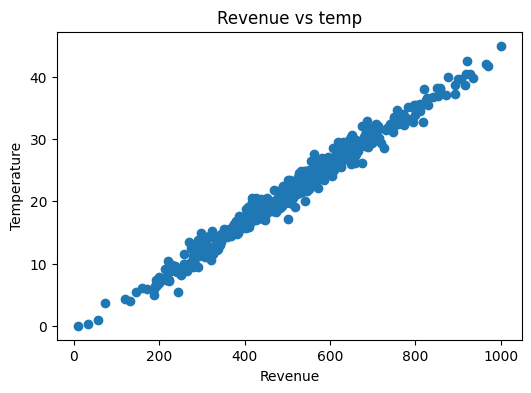

In [99]:
plt.figure(figsize=(6,4))
plt.scatter(df['Revenue'],df['Temperature'])
plt.xlabel('Revenue')
plt.ylabel('Temperature')
plt.title('Revenue vs temp')
plt.savefig("regression_line.png",dpi=300,bbox_inches="tight")
plt.show()

In [100]:
from google.colab import files
files.download("regression_line.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

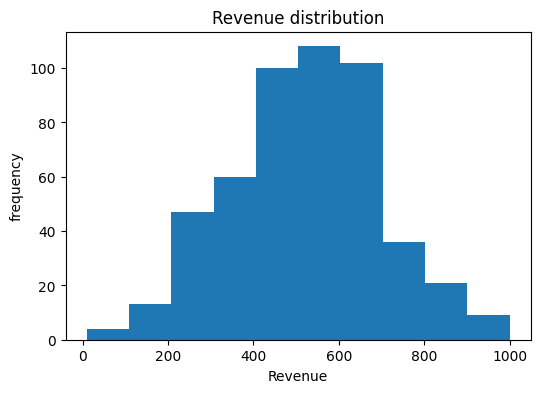

In [89]:
plt.figure(figsize=(6,4))
plt.hist(df['Revenue'],bins=10)
plt.xlabel('Revenue')
plt.ylabel('frequency')
plt.title('Revenue distribution')
plt.savefig("histogram.png",dpi=300,bbox_inches="tight")
plt.show()

In [95]:
from google.colab import files
files.download("histogram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

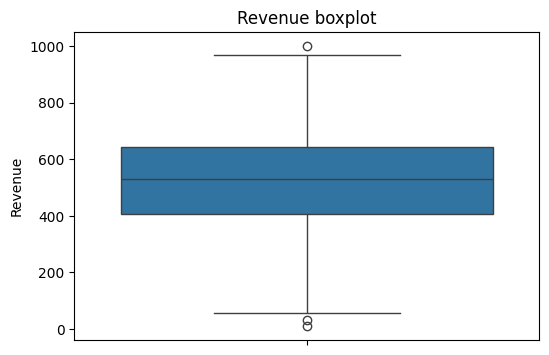

In [90]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Revenue'])
plt.title("Revenue boxplot")
plt.savefig("boxplot.png",dpi=300,bbox_inches="tight")
plt.show()

In [96]:
from google.colab import files
files.download("boxplot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

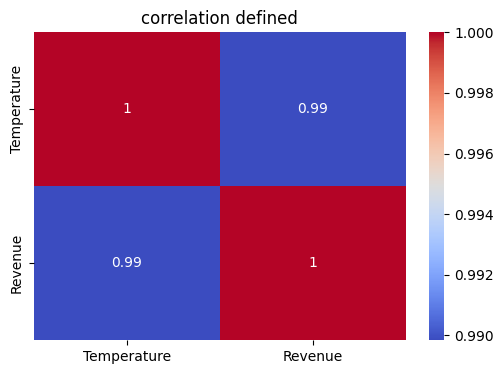

In [91]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("correlation defined")
plt.savefig("correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

In [97]:
from google.colab import files
files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
x=df.drop("Revenue",axis=1)
y=df["Revenue"]

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(400, 1)
(400,)
(100, 1)
(100,)


In [72]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
# slope
print(model.coef_)
# intercept
print(model.intercept_)


[21.38400073]
46.17834580774047


In [70]:
y_pred=model.predict(x_test)
comparison=pd.DataFrame({"Actual": y_test.values,
                         "Predicted": y_pred})
comparison.head()

,Actual,Predicted
0,660,683.421568
1,624,632.099966
2,560,559.394363
3,498,499.519161
4,628,614.992765


In [79]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:", mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 SCORE:",r2)

MAE: 19.195652579103704
MSE: 652.4938284912412
RMSE: 25.543958747446354
R2 SCORE: 0.9771509516333023


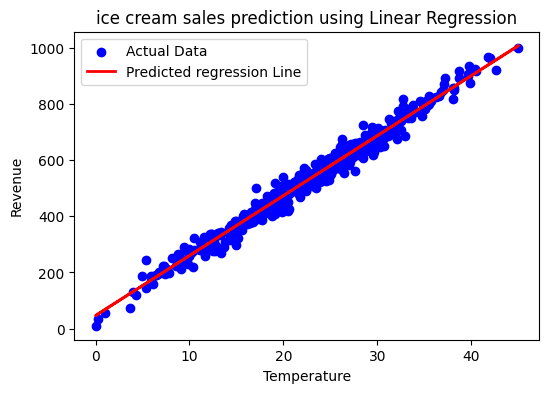

In [93]:
plt.figure(figsize=(6,4))
plt.scatter(x,y,color="Blue",label="Actual Data")
plt.plot(x,model.predict(x),color="red",linewidth=2,label="Predicted regression Line")
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("ice cream sales prediction using Linear Regression")
plt.legend()
plt.savefig("regression_line.png",dpi=300,bbox_inches="tight")
plt.show()



In [98]:
from google.colab import files
files.download("regression_line.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
new_temp=pd.DataFrame({"Temperature":[35]})
new_revenue=model.predict(new_temp)
print("Predicted Revenue:",new_revenue[0])

Predicted Revenue: 794.6183713928374


The Linear Regression model was trained to predict ice cream revenue based on temperature. The model achieved an R² score of 0.977, indicating that temperature explains a significant portion of the variation in revenue. The regression line shows a positive relationship, meaning revenue tends to increase as temperature rises.